# Monte Carlo Simulations in Drug Discovery

Monte Carlo simulations sound complex, but they are **simple and powerful**. They help us **estimate probabilities** by simulating random processes **thousands or millions of times**.

The method is named after **Monte Carlo, the famous casino city**, because just like gambling, it relies on **randomness and chance**. When exact calculations are too difficult, simulations can give **surprisingly accurate answers**.

## Why Monte Carlo in Drug Discovery?
- **Scientists** use them to predict how likely a new drug will succeed.
- **Pharmaceutical companies** use them to model different scenarios before investing millions in lab work.

**Big Idea:** Simulations allow us to test thousands of 'what if' situations **quickly and cheaply.**

## Example 1: Simulating Drug Trial Success Rates 
Suppose a new drug has a 70% chance of passing Phase 1 trials, a 50% chance of passing Phase 2, and a 30% chance of passing Phase 3. We want to know: *What’s the overall probability of success?*

Let’s simulate this process 100,000 times.

In [4]:
import numpy as np

np.random.seed(42)

def simulate_drug_trials(trials=100000):
    success = 0
    for _ in range(trials):
        phase1 = np.random.rand() < 0.7
        phase2 = np.random.rand() < 0.5 if phase1 else False
        phase3 = np.random.rand() < 0.3 if phase2 else False
        if phase3:
            success += 1
    success_rate = success / trials
    return success_rate

estimated_success = simulate_drug_trials()
print(f"Estimated overall success rate: {estimated_success:.2%}")

Estimated overall success rate: 10.41%


## Example 2: Simulating Hit Rates in High-Throughput Screening (HTS) 
Let's have for example, screening 10,000 compounds where each has a 0.5% chance of being active (a 'hit'). Let’s simulate this process 1000 times to see the distribution of hit counts.

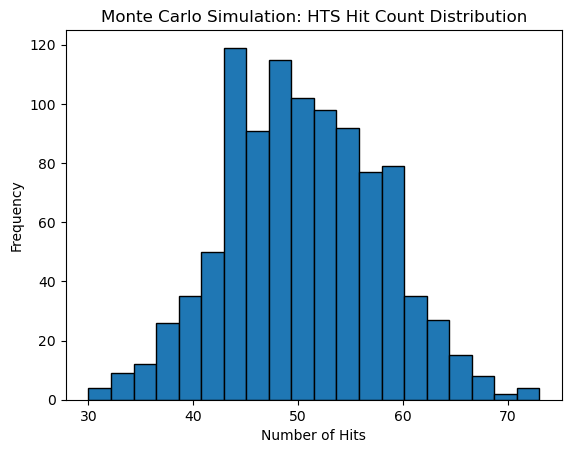

In [9]:
import matplotlib.pyplot as plt

def simulate_hts(screen_size=10000, hit_prob=0.005, simulations=1000):
    hit_counts = []
    for _ in range(simulations):
        hits = np.sum(np.random.rand(screen_size) < hit_prob)
        hit_counts.append(hits)
    return hit_counts

hts_results = simulate_hts()

plt.hist(hts_results, bins=20, edgecolor='black')
plt.title("Monte Carlo Simulation: HTS Hit Count Distribution")
plt.xlabel("Number of Hits")
plt.ylabel("Frequency")
plt.show()

## Example 3: Simulating Binding Affinity Measurements 
Suppose we measure the binding affinity (how tightly a drug binds to its target) for a compound, but the measurement has noise (random error). The true value is 50 nM, and the measurement noise follows a normal distribution with ±10 nM standard deviation.

We’ll simulate 1000 measurements to see the spread.

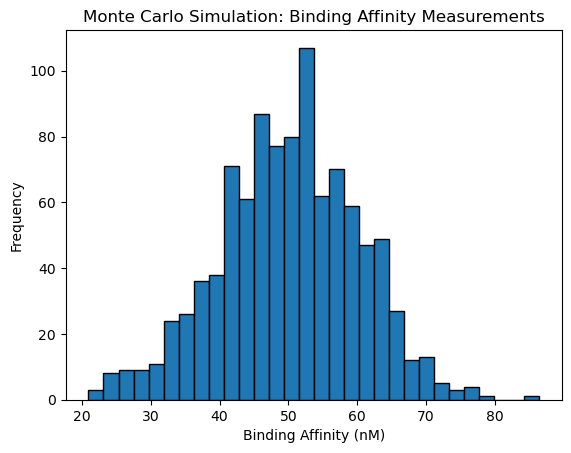

In [12]:
true_affinity = 50  # nM
std_dev = 10
samples = 1000

simulated_affinities = np.random.normal(true_affinity, std_dev, samples)

plt.hist(simulated_affinities, bins=30, edgecolor='black')
plt.title("Monte Carlo Simulation: Binding Affinity Measurements")
plt.xlabel("Binding Affinity (nM)")
plt.ylabel("Frequency")
plt.show()

## Conclusion
Monte Carlo simulations are **hugely valuable in drug discovery**:

- Estimating success probabilities of clinical trials
- Modeling high-throughput screening outcomes
- Understanding measurement variability

By simulating random events, we gain **realistic expectations** and make **better decisions**—long before stepping into the lab.